In [4]:
!pip install prophet lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 917.7 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 13.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 14.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.4 MB/s eta 0:00:00


In [5]:
!pip install prophet

In [9]:
# ============================================================
# 1. Импорты
# ============================================================

from pathlib import Path
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    PROPHET_AVAILABLE = False
    print("Prophet не установлен. Установи: pip install prophet")
    print(e)


# LightGBM
try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM не установлен. Установи: pip install lightgbm")
    print(e)

In [10]:
# ============================================================
# 2. Пути
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

# Берем самый полный датасет, если он есть
DATA_PATH = DATASET_DIR / "demand_training_with_physical_volume.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal_with_ppi.csv"

if not DATA_PATH.exists():
    DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

OUT_DIR = DATASET_DIR / "model_comparison_equal_conditions"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FORECASTS = OUT_DIR / "forecasts_naive_sarimax_prophet_lightgbm.csv"
OUT_MODEL_METRICS = OUT_DIR / "overall_metrics_naive_sarimax_prophet_lightgbm.csv"
OUT_PRODUCT_METRICS = OUT_DIR / "product_metrics_naive_sarimax_prophet_lightgbm.csv"
OUT_CATEGORY_METRICS = OUT_DIR / "category_metrics_naive_sarimax_prophet_lightgbm.csv"
OUT_BEST_PRODUCT = OUT_DIR / "best_model_by_product.csv"
OUT_BEST_CATEGORY = OUT_DIR / "best_model_by_category.csv"
OUT_MODEL_PLOT = OUT_DIR / "overall_model_wape_bar_bw.png"
OUT_CATEGORY_PLOT = OUT_DIR / "category_best_model_wape_bar_bw.png"

print("Используется датасет:", DATA_PATH)
print("Папка вывода:", OUT_DIR)

Используется датасет: /home/senya/projects/diplom/dataset/demand_training_with_physical_volume.csv
Папка вывода: /home/senya/projects/diplom/dataset/model_comparison_equal_conditions


In [11]:
# ============================================================
# 3. Настройки эксперимента
# ============================================================

TARGET_COL = "target_demand_index"

EXCLUDE_ANOMALY_PRODUCTS = True

ANOMALY_PRODUCTS = [
    "Молочные напитки"
]

MIN_TRAIN_OBSERVATIONS = 12

# Сколько последних полных лет берем для rolling-backtest
MAX_CV_FOLDS = 3

# Горизонт прогноза — 4 квартала
FORECAST_HORIZON = 4


# ----------------------------
# Prophet grid
# ----------------------------

TUNE_PROPHET = True

PROPHET_GRID = [
    {"changepoint_prior_scale": 0.01, "seasonality_prior_scale": 1.0},
    {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 5.0},
    {"changepoint_prior_scale": 0.10, "seasonality_prior_scale": 10.0},
]


# ----------------------------
# SARIMAX grid
# ----------------------------

TUNE_SARIMAX = True

SARIMAX_ORDER_GRID = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SARIMAX_SEASONAL_ORDER_GRID = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]

In [12]:
# ============================================================
# 4. Метрики
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):
    return period.to_timestamp(how="end").normalize()

In [13]:
# ============================================================
# 5. Загрузка и подготовка данных
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
    "physical_volume_cumulative_yoy_index": "physical_volume_index",
})

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")
df["year"] = df["period"].dt.year
df["quarter"] = df["period"].dt.quarter

df = df.sort_values(["product_name", "period"]).copy()

if EXCLUDE_ANOMALY_PRODUCTS:
    df = df[~df["product_name"].isin(ANOMALY_PRODUCTS)].copy()

required_cols = [
    "product_name",
    "period",
    "period_end",
    "year",
    "quarter",
    TARGET_COL,
]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"В датасете нет колонки: {col}")

print("Строк:", len(df))
print("Товаров:", df["product_name"].nunique())
print("Период:", df["period"].min(), "—", df["period"].max())

display(df.head())

Строк: 607
Товаров: 18
Период: 2017Q1 — 2025Q4


,period_end,year,quarter,product_code,product_name,group_code,group_name,sales_quarter_thousand_rub,sales_index,consumer_price_index,...,physical_volume_index,physical_rows_count,physical_volume_index_lag1,physical_volume_index_lag4,physical_volume_index_qoq,physical_volume_index_yoy_diff,group_physical_volume_index_mean,market_physical_volume_index_mean,physical_volume_vs_group,physical_volume_vs_market
0,2017-03-31,2017,1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,318147374.6,100.000000,105.627924,...,101.35,1.0,NaN,NaN,NaN,NaN,102.592,100.616316,-1.242,0.733684
1,2017-06-30,2017,2,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,373643153.6,117.443419,106.865372,...,106.04,1.0,101.35,NaN,4.627528,NaN,103.104,100.858421,2.936,5.181579
2,2017-09-30,2017,3,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,421984581.1,132.638084,108.124455,...,108.96,1.0,106.04,NaN,2.753678,NaN,102.546,101.877368,6.414,7.082632
3,2017-12-31,2017,4,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,521008272.3,163.763185,109.377408,...,111.90,1.0,108.96,NaN,2.698238,NaN,103.280,102.494737,8.620,9.405263
4,2018-03-31,2018,1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,379426655.7,119.261288,108.974459,...,116.45,1.0,111.90,101.35,4.066130,15.1,105.840,103.264737,10.610,13.185263


In [14]:
# ============================================================
# 6. Полные проверочные годы для rolling-backtest
# ============================================================

def get_full_years(product_df):
    year_counts = (
        product_df[product_df[TARGET_COL].notna()]
        .groupby("year")["quarter"]
        .nunique()
    )

    return sorted(year_counts[year_counts == 4].index.tolist())


def get_cv_years(product_df):
    full_years = get_full_years(product_df)

    eligible_years = []

    for year in full_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        train_obs = product_df[
            (product_df["period"] <= train_end)
            & (product_df[TARGET_COL].notna())
        ]

        if len(train_obs) >= MIN_TRAIN_OBSERVATIONS:
            eligible_years.append(year)

    return eligible_years[-MAX_CV_FOLDS:]


product_cv_years = {}

for product_name, product_df in df.groupby("product_name"):
    cv_years = get_cv_years(product_df)

    if len(cv_years) > 0:
        product_cv_years[product_name] = cv_years

print("Товаров с доступным rolling-backtest:", len(product_cv_years))

cv_info = pd.DataFrame([
    {
        "product_name": product_name,
        "cv_years": "; ".join(map(str, years)),
        "folds": len(years),
    }
    for product_name, years in product_cv_years.items()
]).sort_values("product_name")

display(cv_info)

Товаров с доступным rolling-backtest: 18


,product_name,cv_years,folds
0,Автомобили легковые,2023; 2024; 2025,3
1,Бензины автомобильные,2020; 2021,2
2,Газовое моторное топливо,2020; 2021; 2022,3
3,Дизельное топливо,2020; 2021; 2022,3
4,"Консервы молочные, молочные составные сухие, с...",2023; 2024; 2025,3
5,"Лампы накаливания (включая галогенные, кроме л...",2022; 2023; 2024,3
6,Макаронные изделия,2023; 2024; 2025,3
7,Маргариновая продукция,2023; 2024; 2025,3
8,Молоко питьевое,2023; 2024; 2025,3
9,Мука,2023; 2024; 2025,3


In [18]:
# ============================================================
# 7. Seasonal Naive
# ============================================================

def seasonal_naive_forecast(train_df, forecast_periods):
    train_df = train_df.set_index("period").sort_index()
    y = train_df[TARGET_COL].astype(float)

    preds = []

    for period in forecast_periods:
        same_quarter_prev_year = period - 4

        if same_quarter_prev_year in y.index and pd.notna(y.loc[same_quarter_prev_year]):
            preds.append(float(y.loc[same_quarter_prev_year]))
        else:
            preds.append(float(y.dropna().iloc[-1]))

    return np.asarray(preds, dtype=float)

In [19]:
# ============================================================
# 8. SARIMAX
# ============================================================

def fit_predict_sarimax(train_df, forecast_periods, order, seasonal_order):
    train_df = train_df.sort_values("period").copy()

    y_train_raw = (
        train_df
        .set_index("period")[TARGET_COL]
        .astype(float)
        .dropna()
        .sort_index()
    )

    train_periods = pd.period_range(
        y_train_raw.index.min(),
        y_train_raw.index.max(),
        freq="Q"
    )

    y_train = y_train_raw.reindex(train_periods)

    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    pred = fitted.forecast(steps=len(forecast_periods))

    return np.asarray(pred, dtype=float)


def choose_sarimax_params(product_df, cv_years):
    if not TUNE_SARIMAX:
        return {
            "order": (1, 1, 1),
            "seasonal_order": (1, 0, 1, 4),
        }

    results = []

    for order, seasonal_order in itertools.product(
        SARIMAX_ORDER_GRID,
        SARIMAX_SEASONAL_ORDER_GRID
    ):
        actual_all = []
        pred_all = []

        for year in cv_years:
            train_end = pd.Period(f"{year - 1}Q4", freq="Q")
            forecast_periods = pd.period_range(
                f"{year}Q1",
                f"{year}Q4",
                freq="Q"
            )

            train_df = product_df[
                (product_df["period"] <= train_end)
                & (product_df[TARGET_COL].notna())
            ].copy()

            test_df = product_df[
                product_df["period"].isin(forecast_periods)
            ].sort_values("period").copy()

            if len(train_df) < MIN_TRAIN_OBSERVATIONS or len(test_df) != 4:
                continue

            if test_df[TARGET_COL].isna().any():
                continue

            try:
                pred = fit_predict_sarimax(
                    train_df=train_df,
                    forecast_periods=forecast_periods,
                    order=order,
                    seasonal_order=seasonal_order
                )

                actual_all.extend(test_df[TARGET_COL].values)
                pred_all.extend(pred)

            except Exception:
                continue

        if len(actual_all) > 0:
            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "wape": calc_wape(actual_all, pred_all),
            })

    if len(results) == 0:
        return {
            "order": (1, 1, 1),
            "seasonal_order": (1, 0, 1, 4),
        }

    best = sorted(results, key=lambda x: x["wape"])[0]

    return {
        "order": best["order"],
        "seasonal_order": best["seasonal_order"],
    }

In [20]:
# ============================================================
# 9. Prophet
# ============================================================

def fit_predict_prophet(train_df, forecast_periods, params=None):
    if not PROPHET_AVAILABLE:
        return None

    if params is None:
        params = {
            "changepoint_prior_scale": 0.05,
            "seasonality_prior_scale": 5.0,
        }

    prophet_train = train_df[["period_end", TARGET_COL]].copy()
    prophet_train = prophet_train.rename(columns={
        "period_end": "ds",
        TARGET_COL: "y",
    })

    prophet_train = prophet_train.dropna()

    if len(prophet_train) < MIN_TRAIN_OBSERVATIONS:
        return None

    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        interval_width=0.95,
    )

    # Для квартальных данных добавляем годовую сезонность
    model.add_seasonality(
        name="yearly_quarterly",
        period=365.25,
        fourier_order=2
    )

    model.fit(prophet_train)

    future = pd.DataFrame({
        "ds": [period_end_date(p) for p in forecast_periods]
    })

    pred = model.predict(future)

    return pred["yhat"].values


def choose_prophet_params(product_df, cv_years):
    if not PROPHET_AVAILABLE:
        return None

    if not TUNE_PROPHET:
        return PROPHET_GRID[1]

    results = []

    for params in PROPHET_GRID:
        actual_all = []
        pred_all = []

        for year in cv_years:
            train_end = pd.Period(f"{year - 1}Q4", freq="Q")
            forecast_periods = pd.period_range(
                f"{year}Q1",
                f"{year}Q4",
                freq="Q"
            )

            train_df = product_df[
                (product_df["period"] <= train_end)
                & (product_df[TARGET_COL].notna())
            ].copy()

            test_df = product_df[
                product_df["period"].isin(forecast_periods)
            ].sort_values("period").copy()

            if len(train_df) < MIN_TRAIN_OBSERVATIONS or len(test_df) != 4:
                continue

            if test_df[TARGET_COL].isna().any():
                continue

            try:
                pred = fit_predict_prophet(
                    train_df=train_df,
                    forecast_periods=forecast_periods,
                    params=params
                )

                if pred is None:
                    continue

                actual_all.extend(test_df[TARGET_COL].values)
                pred_all.extend(pred)

            except Exception:
                continue

        if len(actual_all) > 0:
            results.append({
                "params": params,
                "wape": calc_wape(actual_all, pred_all),
            })

    if len(results) == 0:
        return PROPHET_GRID[1]

    best = sorted(results, key=lambda x: x["wape"])[0]

    return best["params"]

In [21]:
# ============================================================
# 10. LightGBM
#
# В равных условиях:
# - не используем внешние факторы;
# - используем только историю целевой переменной;
# - модель глобальная по всем товарам;
# - прогноз рекурсивный на 4 квартала вперед.
# ============================================================

def add_lgb_features(data):
    data = data.sort_values(["product_name", "period"]).copy()

    min_year = data["period"].dt.year.min()

    data["time_idx"] = (
        (data["period"].dt.year - min_year) * 4
        + data["period"].dt.quarter
    )

    data["quarter_num"] = data["period"].dt.quarter
    data["year_num"] = data["period"].dt.year

    # лаги целевой переменной
    data["target_lag1"] = data.groupby("product_name")[TARGET_COL].shift(1)
    data["target_lag2"] = data.groupby("product_name")[TARGET_COL].shift(2)
    data["target_lag4"] = data.groupby("product_name")[TARGET_COL].shift(4)

    data["target_roll4_mean"] = (
        data.groupby("product_name")[TARGET_COL]
        .shift(1)
        .rolling(4)
        .mean()
        .reset_index(level=0, drop=True)
    )

    data["target_roll4_std"] = (
        data.groupby("product_name")[TARGET_COL]
        .shift(1)
        .rolling(4)
        .std()
        .reset_index(level=0, drop=True)
    )

    data["target_yoy_diff"] = (
        data["target_lag1"]
        - data.groupby("product_name")[TARGET_COL].shift(5)
    )

    return data


LGB_FEATURE_COLS_BASE = [
    "product_name",
    "group_name",
    "quarter_num",
    "time_idx",
    "target_lag1",
    "target_lag2",
    "target_lag4",
    "target_roll4_mean",
    "target_roll4_std",
    "target_yoy_diff",
]


def prepare_lgb_train_frame(data, train_end):
    work = add_lgb_features(data)

    train = work[
        (work["period"] <= train_end)
        & (work[TARGET_COL].notna())
    ].copy()

    train = train.dropna(subset=[
        "target_lag1",
        "target_lag2",
        "target_lag4",
        "target_roll4_mean",
    ])

    feature_cols = [col for col in LGB_FEATURE_COLS_BASE if col in train.columns]

    X = train[feature_cols].copy()
    y = train[TARGET_COL].astype(float).copy()

    for cat_col in ["product_name", "group_name"]:
        if cat_col in X.columns:
            X[cat_col] = X[cat_col].astype("category")

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    numeric_medians = X[numeric_cols].median(numeric_only=True)

    X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X[numeric_cols] = X[numeric_cols].fillna(numeric_medians)

    return X, y, feature_cols, numeric_medians


def make_lgb_forecast_row(product_name, period, history_y, data, feature_cols, numeric_medians):
    product_hist = data[data["product_name"] == product_name].sort_values("period").copy()

    if product_hist.empty:
        return None

    group_name = (
        product_hist["group_name"].dropna().iloc[0]
        if "group_name" in product_hist.columns and product_hist["group_name"].notna().any()
        else None
    )

    min_year = data["period"].dt.year.min()

    row = {
        "product_name": product_name,
        "group_name": group_name,
        "quarter_num": period.quarter,
        "time_idx": (period.year - min_year) * 4 + period.quarter,

        "target_lag1": history_y.get(period - 1, np.nan),
        "target_lag2": history_y.get(period - 2, np.nan),
        "target_lag4": history_y.get(period - 4, np.nan),
    }

    previous_periods = [period - i for i in range(1, 5)]
    previous_values = [history_y.get(p, np.nan) for p in previous_periods]
    previous_values_clean = [v for v in previous_values if pd.notna(v)]

    row["target_roll4_mean"] = (
        np.mean(previous_values_clean)
        if len(previous_values_clean) > 0
        else np.nan
    )

    row["target_roll4_std"] = (
        np.std(previous_values_clean, ddof=1)
        if len(previous_values_clean) >= 2
        else 0
    )

    lag5 = history_y.get(period - 5, np.nan)

    row["target_yoy_diff"] = (
        row["target_lag1"] - lag5
        if pd.notna(row["target_lag1"]) and pd.notna(lag5)
        else np.nan
    )

    X_one = pd.DataFrame([row])

    for col in feature_cols:
        if col not in X_one.columns:
            X_one[col] = np.nan

    X_one = X_one[feature_cols].copy()

    for cat_col in ["product_name", "group_name"]:
        if cat_col in X_one.columns:
            X_one[cat_col] = X_one[cat_col].astype("category")

    numeric_cols = X_one.select_dtypes(include=[np.number]).columns.tolist()

    X_one[numeric_cols] = X_one[numeric_cols].replace([np.inf, -np.inf], np.nan)
    X_one[numeric_cols] = X_one[numeric_cols].fillna(numeric_medians)

    return X_one

In [22]:
# ============================================================
# 11. Rolling-backtest:
# Seasonal Naive + SARIMAX + Prophet
# ============================================================

forecast_rows = []
model_param_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()

    if product_name not in product_cv_years:
        continue

    cv_years = product_cv_years[product_name]

    product_code = (
        product_df["product_code"].dropna().iloc[0]
        if "product_code" in product_df.columns and product_df["product_code"].notna().any()
        else None
    )

    group_code = (
        product_df["group_code"].dropna().iloc[0]
        if "group_code" in product_df.columns and product_df["group_code"].notna().any()
        else None
    )

    group_name = (
        product_df["group_name"].dropna().iloc[0]
        if "group_name" in product_df.columns and product_df["group_name"].notna().any()
        else None
    )

    print("=" * 100)
    print("Товар:", product_name)
    print("CV годы:", cv_years)

    # ----------------------------
    # Подбор SARIMAX
    # ----------------------------

    sarimax_params = choose_sarimax_params(product_df, cv_years)

    print("SARIMAX:", sarimax_params)

    model_param_rows.append({
        "product_name": product_name,
        "model": "sarimax",
        "params": str(sarimax_params),
    })

    # ----------------------------
    # Подбор Prophet
    # ----------------------------

    prophet_params = None

    if PROPHET_AVAILABLE:
        prophet_params = choose_prophet_params(product_df, cv_years)
        print("Prophet:", prophet_params)

        model_param_rows.append({
            "product_name": product_name,
            "model": "prophet",
            "params": str(prophet_params),
        })

    # ----------------------------
    # Rolling-backtest по годам
    # ----------------------------

    for year in cv_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")
        forecast_periods = pd.period_range(
            f"{year}Q1",
            f"{year}Q4",
            freq="Q"
        )

        train_df = product_df[
            (product_df["period"] <= train_end)
            & (product_df[TARGET_COL].notna())
        ].copy()

        test_df = product_df[
            product_df["period"].isin(forecast_periods)
        ].sort_values("period").copy()

        if len(train_df) < MIN_TRAIN_OBSERVATIONS or len(test_df) != 4:
            continue

        if test_df[TARGET_COL].isna().any():
            continue

        # ----------------------------
        # Seasonal Naive
        # ----------------------------

        try:
            pred_naive = seasonal_naive_forecast(
                train_df=train_df,
                forecast_periods=forecast_periods
            )

            for i, period in enumerate(forecast_periods):
                forecast_rows.append({
                    "model": "seasonal_naive",
                    "product_code": product_code,
                    "product_name": product_name,
                    "group_code": group_code,
                    "group_name": group_name,
                    "cv_year": year,
                    "period": str(period),
                    "period_end": period_end_date(period),
                    "train_start": str(train_df["period"].min()),
                    "train_end": str(train_end),
                    "actual_target_demand_index": test_df[TARGET_COL].iloc[i],
                    "forecast_target_demand_index": pred_naive[i],
                    "model_params": "same quarter previous year",
                })

        except Exception as e:
            print("Seasonal Naive error:", product_name, year, e)

        # ----------------------------
        # SARIMAX
        # ----------------------------

        try:
            pred_sarimax = fit_predict_sarimax(
                train_df=train_df,
                forecast_periods=forecast_periods,
                order=sarimax_params["order"],
                seasonal_order=sarimax_params["seasonal_order"],
            )

            for i, period in enumerate(forecast_periods):
                forecast_rows.append({
                    "model": "sarimax",
                    "product_code": product_code,
                    "product_name": product_name,
                    "group_code": group_code,
                    "group_name": group_name,
                    "cv_year": year,
                    "period": str(period),
                    "period_end": period_end_date(period),
                    "train_start": str(train_df["period"].min()),
                    "train_end": str(train_end),
                    "actual_target_demand_index": test_df[TARGET_COL].iloc[i],
                    "forecast_target_demand_index": pred_sarimax[i],
                    "model_params": str(sarimax_params),
                })

        except Exception as e:
            print("SARIMAX error:", product_name, year, e)

        # ----------------------------
        # Prophet
        # ----------------------------

        if PROPHET_AVAILABLE:
            try:
                pred_prophet = fit_predict_prophet(
                    train_df=train_df,
                    forecast_periods=forecast_periods,
                    params=prophet_params,
                )

                if pred_prophet is not None:
                    for i, period in enumerate(forecast_periods):
                        forecast_rows.append({
                            "model": "prophet",
                            "product_code": product_code,
                            "product_name": product_name,
                            "group_code": group_code,
                            "group_name": group_name,
                            "cv_year": year,
                            "period": str(period),
                            "period_end": period_end_date(period),
                            "train_start": str(train_df["period"].min()),
                            "train_end": str(train_end),
                            "actual_target_demand_index": test_df[TARGET_COL].iloc[i],
                            "forecast_target_demand_index": pred_prophet[i],
                            "model_params": str(prophet_params),
                        })

            except Exception as e:
                print("Prophet error:", product_name, year, e)

Товар: Автомобили легковые
CV годы: [2023, 2024, 2025]


19:45:29 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing


SARIMAX: {'order': (1, 1, 2), 'seasonal_order': (0, 0, 1, 4)}


19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing
19:45:30 - cmdstanpy - INFO - Chain [1] start processing
19:45:30 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


...

19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing


SARIMAX: {'order': (2, 1, 1), 'seasonal_order': (1, 0, 1, 4)}


19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:11 - cmdstanpy - INFO - Chain [1] done processing
19:46:11 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing
19:46:12 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing
19:46:12 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing
19:46:12 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


19:46:12 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing
19:46:12 - cmdstanpy - INFO - Chain [1] start processing
19:46:12 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
# ============================================================
# 12. Rolling-backtest:
# LightGBM global
# ============================================================

if LIGHTGBM_AVAILABLE:

    all_cv_years = sorted(
        set(year for years in product_cv_years.values() for year in years)
    )

    for year in all_cv_years:

        print("=" * 100)
        print("LightGBM CV year:", year)

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")
        forecast_periods = pd.period_range(
            f"{year}Q1",
            f"{year}Q4",
            freq="Q"
        )

        X_train, y_train, feature_cols, numeric_medians = prepare_lgb_train_frame(
            data=df,
            train_end=train_end
        )

        if len(X_train) < 30:
            print("Недостаточно строк для LightGBM:", year)
            continue

        model_lgb = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=15,
            min_child_samples=8,
            subsample=0.90,
            colsample_bytree=0.90,
            objective="regression",
            random_state=42,
            verbose=-1,
        )

        categorical_features = [
            col for col in ["product_name", "group_name"]
            if col in X_train.columns
        ]

        model_lgb.fit(
            X_train,
            y_train,
            categorical_feature=categorical_features
        )

        for product_name, product_df in df.groupby("product_name"):

            if product_name not in product_cv_years:
                continue

            if year not in product_cv_years[product_name]:
                continue

            product_df = product_df.sort_values("period").copy()

            train_df = product_df[
                (product_df["period"] <= train_end)
                & (product_df[TARGET_COL].notna())
            ].copy()

            test_df = product_df[
                product_df["period"].isin(forecast_periods)
            ].sort_values("period").copy()

            if len(train_df) < MIN_TRAIN_OBSERVATIONS or len(test_df) != 4:
                continue

            if test_df[TARGET_COL].isna().any():
                continue

            product_code = (
                product_df["product_code"].dropna().iloc[0]
                if "product_code" in product_df.columns and product_df["product_code"].notna().any()
                else None
            )

            group_code = (
                product_df["group_code"].dropna().iloc[0]
                if "group_code" in product_df.columns and product_df["group_code"].notna().any()
                else None
            )

            group_name = (
                product_df["group_name"].dropna().iloc[0]
                if "group_name" in product_df.columns and product_df["group_name"].notna().any()
                else None
            )

            history_y = (
                train_df
                .set_index("period")[TARGET_COL]
                .astype(float)
                .to_dict()
            )

            preds = []

            for period in forecast_periods:

                X_one = make_lgb_forecast_row(
                    product_name=product_name,
                    period=period,
                    history_y=history_y,
                    data=df,
                    feature_cols=feature_cols,
                    numeric_medians=numeric_medians,
                )

                if X_one is None:
                    pred_value = np.nan
                else:
                    pred_value = float(model_lgb.predict(X_one)[0])

                preds.append(pred_value)

                # рекурсивно используем прогноз как лаг для следующих кварталов
                history_y[period] = pred_value

            for i, period in enumerate(forecast_periods):
                forecast_rows.append({
                    "model": "lightgbm_global",
                    "product_code": product_code,
                    "product_name": product_name,
                    "group_code": group_code,
                    "group_name": group_name,
                    "cv_year": year,
                    "period": str(period),
                    "period_end": period_end_date(period),
                    "train_start": str(train_df["period"].min()),
                    "train_end": str(train_end),
                    "actual_target_demand_index": test_df[TARGET_COL].iloc[i],
                    "forecast_target_demand_index": preds[i],
                    "model_params": "global LightGBM with target lags only",
                })

LightGBM CV year: 2020
LightGBM CV year: 2021
LightGBM CV year: 2022
LightGBM CV year: 2023
LightGBM CV year: 2024
LightGBM CV year: 2025


In [24]:
# ============================================================
# 13. Сбор прогнозов
# ============================================================

forecasts = pd.DataFrame(forecast_rows)

if forecasts.empty:
    raise ValueError("Не построено ни одного прогноза. Проверь данные и доступность моделей.")

forecasts = forecasts[
    forecasts["actual_target_demand_index"].notna()
    & forecasts["forecast_target_demand_index"].notna()
].copy()

forecasts["error"] = (
    forecasts["forecast_target_demand_index"]
    - forecasts["actual_target_demand_index"]
)

forecasts["abs_error"] = forecasts["error"].abs()

forecasts["ape_%"] = (
    forecasts["abs_error"]
    / forecasts["actual_target_demand_index"].abs()
    * 100
)

forecasts.to_csv(
    OUT_FORECASTS,
    index=False,
    encoding="utf-8-sig"
)

print("Всего прогнозных строк:", len(forecasts))
display(forecasts.head())

Всего прогнозных строк: 848


,model,product_code,product_name,group_code,group_name,cv_year,period,period_end,train_start,train_end,actual_target_demand_index,forecast_target_demand_index,model_params,error,abs_error,ape_%
0,seasonal_naive,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q1,2023-03-31,2017Q1,2022Q4,118.327224,156.617409,same quarter previous year,38.290185,38.290185,32.359573
1,seasonal_naive,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q2,2023-06-30,2017Q1,2022Q4,153.480192,111.325493,same quarter previous year,-42.154699,42.154699,27.465889
2,seasonal_naive,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q3,2023-09-30,2017Q1,2022Q4,187.270948,101.264365,same quarter previous year,-86.006583,86.006583,45.926282
3,seasonal_naive,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q4,2023-12-31,2017Q1,2022Q4,166.589977,102.055567,same quarter previous year,-64.534410,64.534410,38.738471
4,sarimax,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q1,2023-03-31,2017Q1,2022Q4,118.327224,128.463737,"{'order': (1, 1, 2), 'seasonal_order': (0, 0, ...",10.136513,10.136513,8.566509


In [30]:
# ============================================================
# 14. Общие метрики по моделям
# ============================================================

model_rows = []

for model_name, temp in forecasts.groupby("model"):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    model_rows.append({
        "model": model_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

model_metrics = (
    pd.DataFrame(model_rows)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

model_metrics.to_csv(
    OUT_MODEL_METRICS,
    index=False,
    encoding="utf-8-sig"
)

display(model_metrics)

,model,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax,18,212,2020; 2021; 2022; 2023; 2024; 2025,11.042982,18.343409,8.786827,9.134752
1,prophet,18,212,2020; 2021; 2022; 2023; 2024; 2025,11.190205,17.486271,9.100003,9.256536
2,seasonal_naive,18,212,2020; 2021; 2022; 2023; 2024; 2025,12.750520,19.990420,10.083682,10.547228
3,lightgbm_global,18,212,2020; 2021; 2022; 2023; 2024; 2025,13.260567,19.827635,11.285864,10.969138


In [32]:
# ============================================================
# 15. Метрики по товарам
# ============================================================

product_rows = []

for (model_name, product_code, product_name, group_code, group_name), temp in forecasts.groupby(
    ["model", "product_code", "product_name", "group_code", "group_name"],
    dropna=False
):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    product_rows.append({
        "model": model_name,
        "product_code": product_code,
        "product_name": product_name,
        "group_code": group_code,
        "group_name": group_name,
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "observations_count": len(temp),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

product_metrics = (
    pd.DataFrame(product_rows)
    .sort_values(["product_name", "WAPE_%"])
    .reset_index(drop=True)
)

product_metrics.to_csv(
    OUT_PRODUCT_METRICS,
    index=False,
    encoding="utf-8-sig"
)

display(product_metrics)

,model,product_code,product_name,group_code,group_name,cv_years,observations_count,MAE,RMSE,MAPE_%,WAPE_%
0,prophet,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,23.551980,29.701085,13.538456,13.917920
1,sarimax,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,28.106378,35.796672,16.166118,16.609317
2,lightgbm_global,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,32.771413,39.866798,18.910141,19.366095
3,seasonal_naive,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,42.310382,47.045379,25.580847,25.003099
4,prophet,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2020; 2021,8,5.557467,8.553129,5.731495,5.278142
...,...,...,...,...,...,...,...,...,...,...,...
67,lightgbm_global,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,5.544214,6.358294,5.883239,5.558606
68,sarimax,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,7.998177,10.999897,6.139605,6.247476
69,prophet,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,8.402677,10.400769,6.575484,6.563437
70,seasonal_naive,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,9.234656,12.376024,7.040370,7.213306


In [33]:
# ============================================================
# 16. Метрики по категориям
# ============================================================

category_rows = []

for (model_name, group_code, group_name), temp in forecasts.groupby(
    ["model", "group_code", "group_name"],
    dropna=False
):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append({
        "model": model_name,
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_metrics = (
    pd.DataFrame(category_rows)
    .sort_values(["group_name", "WAPE_%"])
    .reset_index(drop=True)
)

category_metrics.to_csv(
    OUT_CATEGORY_METRICS,
    index=False,
    encoding="utf-8-sig"
)

display(category_metrics)

,model,group_code,group_name,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,4.563887,5.487578,5.080822,4.978415
1,seasonal_naive,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,4.587133,5.395603,5.133435,5.003773
2,prophet,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,5.323045,7.812462,5.540941,5.806526
3,lightgbm_global,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,6.463558,7.945751,7.308325,7.050630
4,sarimax,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,9.069238,12.426884,7.728180,7.386670
5,seasonal_naive,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,10.125969,13.302873,8.577566,8.247351
6,prophet,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,10.735411,13.755093,9.151495,8.743727
7,lightgbm_global,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,12.098899,15.314741,10.453133,9.854254
8,prophet,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,3.236229,4.207052,2.856048,2.896274
9,sarimax,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,3.247407,4.778319,2.743290,2.906278


In [34]:
# ============================================================
# 17. Лучшая модель по каждому товару
# ============================================================

best_by_product = (
    product_metrics
    .sort_values(["product_name", "WAPE_%"])
    .groupby("product_name", as_index=False)
    .head(1)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

best_by_product.to_csv(
    OUT_BEST_PRODUCT,
    index=False,
    encoding="utf-8-sig"
)

display(best_by_product)

,model,product_code,product_name,group_code,group_name,cv_years,observations_count,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax,S_мясо_животных,Мясо животных,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,2.572744,3.464912,2.453192,2.493222
1,prophet,S_мясо_домашней_птицы,Мясо домашней птицы,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,3.741846,4.741986,3.029750,3.110796
2,seasonal_naive,S_мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,3.914888,5.231372,3.773490,3.808711
3,sarimax,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,3.890725,5.039406,4.029618,3.900825
4,sarimax,S_свежие_овощи,Свежие овощи,G04,"Овощи, фрукты и картофель",2023; 2024; 2025,12,6.025002,8.622210,4.437742,4.280886
5,sarimax,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,4.941394,6.470484,4.291904,4.308761
6,sarimax,S_молоко_питьевое,Молоко питьевое,G02,Молочная продукция и яйца,2023; 2024; 2025,12,6.139466,6.894648,4.829834,4.894043
7,prophet,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2020; 2021,8,5.557467,8.553129,5.731495,5.278142
8,sarimax,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,2020; 2021; 2022,12,7.102132,10.173836,5.792487,5.363317
9,seasonal_naive,S_маргариновая_продукция,Маргариновая продукция,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,4.680531,5.484403,5.599600,5.598327


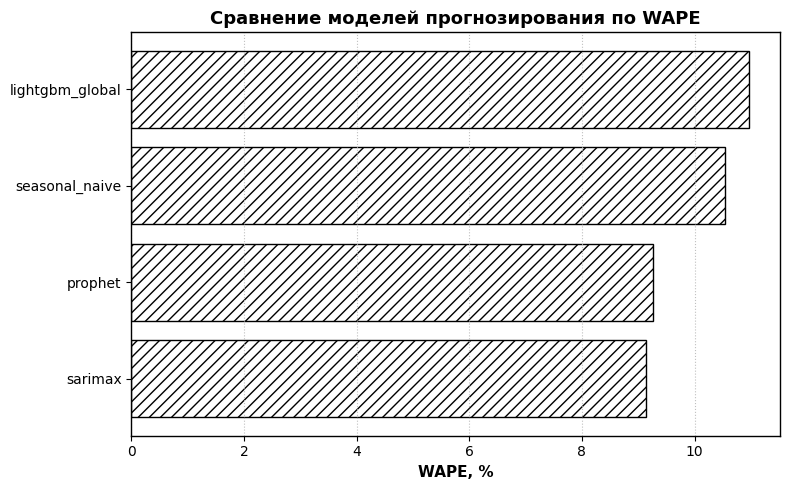

График сохранен: /home/senya/projects/diplom/dataset/model_comparison_equal_conditions/overall_model_wape_bar_bw.png


In [35]:
# ============================================================
# 20. ЧБ-график общего сравнения моделей
# ============================================================

plot_df = model_metrics.sort_values("WAPE_%", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_df["model"],
    plot_df["WAPE_%"],
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.0
)

ax.set_xlabel("WAPE, %", fontsize=11, fontweight="bold")
ax.set_title(
    "Сравнение моделей прогнозирования по WAPE",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    linestyle=":",
    linewidth=0.8,
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()

plt.savefig(
    OUT_MODEL_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("График сохранен:", OUT_MODEL_PLOT)

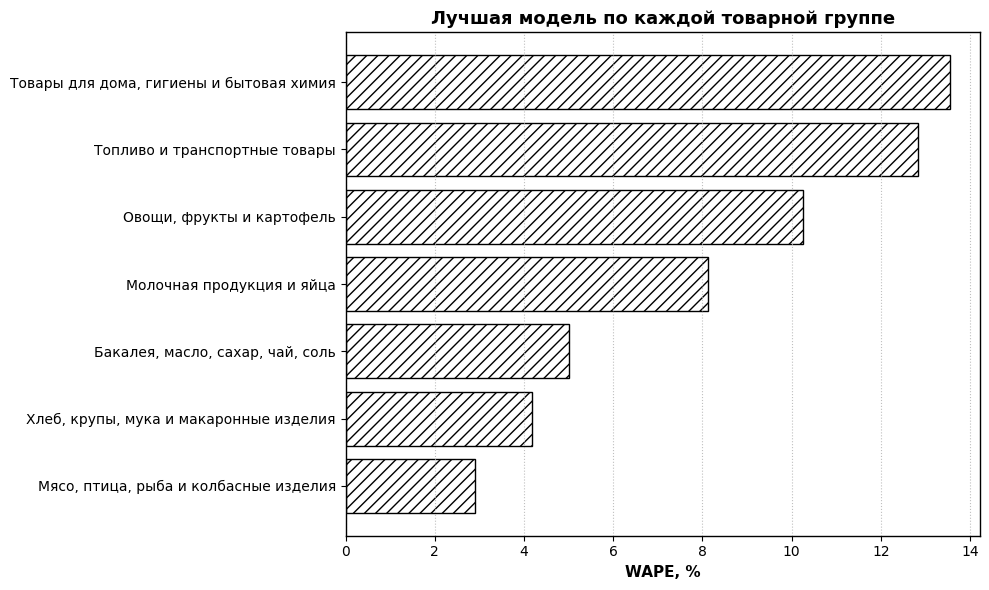

График сохранен: /home/senya/projects/diplom/dataset/model_comparison_equal_conditions/category_best_model_wape_bar_bw.png


In [36]:
# ============================================================
# 21. ЧБ-график лучших моделей по категориям
# ============================================================

plot_cat = best_by_category.sort_values("WAPE_%", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_cat["group_name"],
    plot_cat["WAPE_%"],
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.0
)

ax.set_xlabel("WAPE, %", fontsize=11, fontweight="bold")
ax.set_title(
    "Лучшая модель по каждой товарной группе",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    linestyle=":",
    linewidth=0.8,
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()

plt.savefig(
    OUT_CATEGORY_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("График сохранен:", OUT_CATEGORY_PLOT)